# Online Retail Data Analysis

## Objective
Analyze customer behavior, sales trends, and product performance using Python.

In [155]:
import pandas as pd
import numpy as np

In [156]:
df = pd.read_csv('Online_Retail.csv', encoding='latin1')

# 1. Dataset Description
- Transactions from an online retail store
- Contains invoices, products, customers, and countries

In [157]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [158]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [159]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [160]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [161]:
df.shape

(541909, 8)

## 2. Data Cleaning
- Removed missing CustomerID
- Removed negative Quantity (returns)
- Removed duplicates
- Converted dates
- Created TotalPrice column

In [162]:
df[df['CustomerID'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


In [163]:
df = df.dropna(subset=['CustomerID'])  # removed rows with missing CustomerID

In [164]:
df.isnull().sum() #checking for null values after dropping rows with missing CustomerID

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [166]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']) # Convert InvoiceDate to datetime format

In [167]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice'] # Create a new column for total price

In [168]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [169]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,406829.000000,406829,406829.000000,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207424,3.460471,15287.690570,20.401854
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000,4.200000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000,11.100000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,248.693370,NaN,69.315162,1713.600303,427.591718


In [170]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)] # Filter out rows with non-positive Quantity and UnitPrice

In [171]:
df.duplicated().sum() # Check for duplicate rows

np.int64(5192)

In [172]:
df = df.drop_duplicates() # Remove duplicate rows

In [173]:
df.duplicated().sum()

np.int64(0)

In [174]:
df.shape
df.describe() # Check the summary statistics after cleaning the data

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [176]:
df['CustomerID'] = df['CustomerID'].astype(str) # Convert CustomerID to string type for better handling of categorical data

In [177]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,168469.600000
std,180.492832,NaN,22.241836,311.099224


In [178]:
df.shape

(392692, 9)

# 3. Exploratory Data Analysis
## Top Products by Revenue

In [179]:
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_products.head(10)               # Display the top 10 products by total sales

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64

In [180]:
top_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_quantity.head(10)               # Display the top 10 products by quantity sold

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [181]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_customers.head(10)              # Display the top 10 customers by total spending

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

In [182]:
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
country_revenue.head(10)             # Display the top 10 countries by total revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

# 4. Monthly Revenue Trend

In [183]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month # Extract year and month from InvoiceDate for time-based analysis

In [184]:
monthly_revenue = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
monthly_revenue.head() # Display the monthly revenue to analyze trends over time

,Year,Month,TotalPrice
0,2010,12,570422.730
1,2011,1,568101.310
2,2011,2,446084.920
3,2011,3,594081.760
4,2011,4,468374.331


In [185]:
monthly_revenue['YearMonth'] = monthly_revenue['Year'].astype(str) + '-' + monthly_revenue['Month'].astype(str)
monthly_revenue.head() # Create a YearMonth column for easier plotting of monthly revenue trends

,Year,Month,TotalPrice,YearMonth
0,2010,12,570422.730,2010-12
1,2011,1,568101.310,2011-1
2,2011,2,446084.920,2011-2
3,2011,3,594081.760,2011-3
4,2011,4,468374.331,2011-4


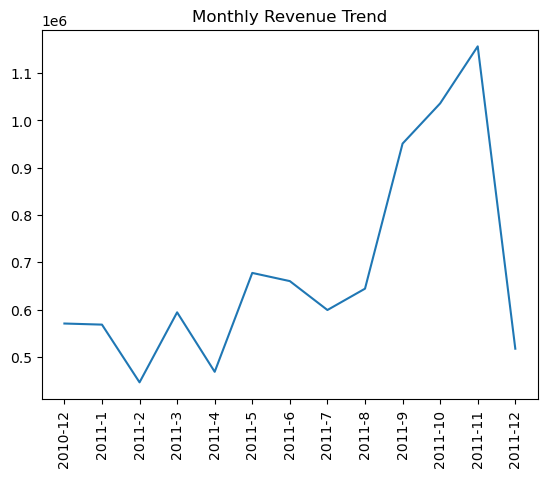

In [186]:
import matplotlib.pyplot as plt 

plt.figure()
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['TotalPrice'])
plt.xticks(rotation=90)
plt.title('Monthly Revenue Trend')
plt.show()                                  # Plot the monthly revenue trend over time

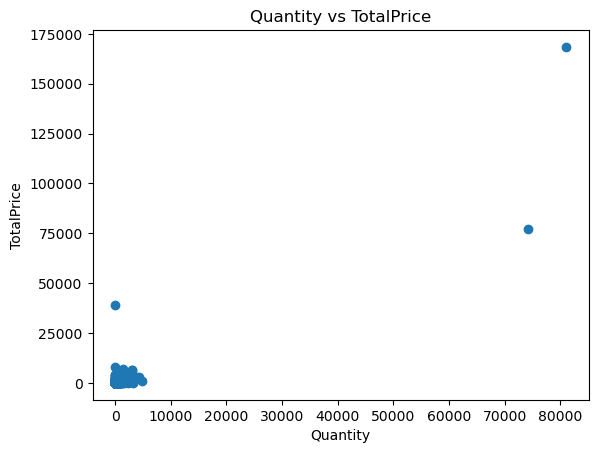

In [187]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['Quantity'], df['TotalPrice'])
plt.title('Quantity vs TotalPrice')
plt.xlabel('Quantity')
plt.ylabel('TotalPrice')
plt.show()

In [188]:
df[['Quantity', 'UnitPrice', 'TotalPrice']].corr() # Calculate the correlation between Quantity, UnitPrice, and TotalPrice to understand their relationships

,Quantity,UnitPrice,TotalPrice
Quantity,1.000000,-0.004578,0.914451
UnitPrice,-0.004578,1.000000,0.081619
TotalPrice,0.914451,0.081619,1.000000


In [189]:
last_date = df['InvoiceDate'].max()
last_date

Timestamp('2011-12-09 12:50:00')

# 5. Customer Analysis (RFM)
- R means Recency. How recently did a customer buy something. Lower days = Better customer
- F means Frequency. How often do they buy? 
- M means Monetary. How much money do they spend? Big spenders = more valuable customer

In [190]:
customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (last_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})                                                   # Create a customer-level dataframe for RFM analysis

In [191]:
customer_df.columns = ['Recency', 'Frequency', 'Monetary']
customer_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


In [192]:
customer_df.describe() # Check the summary statistics of the customer-level dataframe to understand the distribution of Recency, Frequency, and Monetary values

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,90.523744,2048.688081
std,100.014169,225.506968,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,17.000000,306.482500
50%,50.000000,41.000000,668.570000
75%,141.000000,98.000000,1660.597500
max,373.000000,7676.000000,280206.020000


In [193]:
customer_df.sort_values('Monetary', ascending=False).head(10) # Display the top 10 customers by total spending (Monetary value)

,Recency,Frequency,Monetary
CustomerID,,,
14646.0,1,2076,280206.02
18102.0,0,431,259657.30
17450.0,7,336,194390.79
16446.0,0,3,168472.50
14911.0,0,5670,143711.17
12415.0,23,714,124914.53
14156.0,9,1395,117210.08
17511.0,2,963,91062.38
16029.0,38,241,80850.84


In [194]:
customer_df['R_rank'] = customer_df['Recency'].rank(ascending=False)
customer_df['F_rank'] = customer_df['Frequency'].rank(ascending=True)
customer_df['M_rank'] = customer_df['Monetary'].rank(ascending=True) # Rank customers based on Recency, Frequency, and Monetary values for RFM segmentation

In [195]:
customer_df['R_score'] = pd.qcut(customer_df['R_rank'], 4, labels=[4,3,2,1])
customer_df['F_score'] = pd.qcut(customer_df['F_rank'], 4, labels=[1,2,3,4])
customer_df['M_score'] = pd.qcut(customer_df['M_rank'], 4, labels=[1,2,3,4]) # Create RFM scores by categorizing the ranks into quartiles (1 to 4) for Recency, Frequency, and Monetary values

In [196]:
customer_df['RFM_Score'] = customer_df['R_score'].astype(str) + \
                           customer_df['F_score'].astype(str) + \
                           customer_df['M_score'].astype(str)

customer_df.head() # Combine R, F, and M scores into a single RFM_Score for easier segmentation of customers based on their purchasing behavior

,Recency,Frequency,Monetary,R_rank,F_rank,M_rank,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,,,,
12346.0,325,1,77183.60,161.0,36.0,4329.0,4,1,4,414
12347.0,1,182,4310.00,4202.5,3827.5,4004.0,1,4,4,144
12348.0,74,31,1797.24,1653.0,1837.0,3335.0,3,2,4,324
12349.0,18,73,1757.55,3182.0,2910.5,3312.0,2,3,4,234
12350.0,309,17,334.40,230.5,1082.5,1242.0,4,1,2,412


In [197]:
def segment(row):
    if row['RFM_Score'] == '444':
        return 'Best Customers'
    elif row['F_score'] == 4:
        return 'Loyal Customers'
    elif row['R_score'] == 4:
        return 'Recent Customers'
    else:
        return 'Others'

customer_df['Segment'] = customer_df.apply(segment, axis=1) # Segment customers based on their RFM scores to identify different customer groups for targeted marketing strategies

In [198]:
customer_df['Segment'].value_counts() # Display the count of customers in each segment to understand the distribution of customer groups based on their purchasing behavior

Segment
Others              2216
Loyal Customers     1058
Recent Customers    1042
Best Customers        22
Name: count, dtype: int64

In [199]:
customer_df.head().sort_values('RFM_Score', ascending=False) # Display the top customers based on their RFM scores to identify high-value customers for targeted marketing efforts

,Recency,Frequency,Monetary,R_rank,F_rank,M_rank,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,,,,
12346.0,325,1,77183.60,161.0,36.0,4329.0,4,1,4,414,Recent Customers
12350.0,309,17,334.40,230.5,1082.5,1242.0,4,1,2,412,Recent Customers
12348.0,74,31,1797.24,1653.0,1837.0,3335.0,3,2,4,324,Others
12349.0,18,73,1757.55,3182.0,2910.5,3312.0,2,3,4,234,Others
12347.0,1,182,4310.00,4202.5,3827.5,4004.0,1,4,4,144,Loyal Customers


In [200]:
df['CustomerID'].nunique()

4338

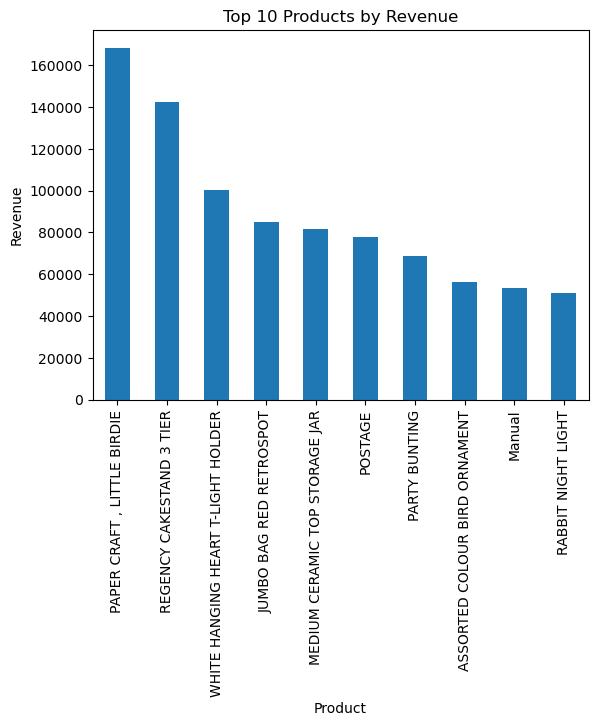

In [201]:
import matplotlib.pyplot as plt

top_products.head(10).plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show() # Plot the top 10 products by revenue to visualize which products are generating the most sales

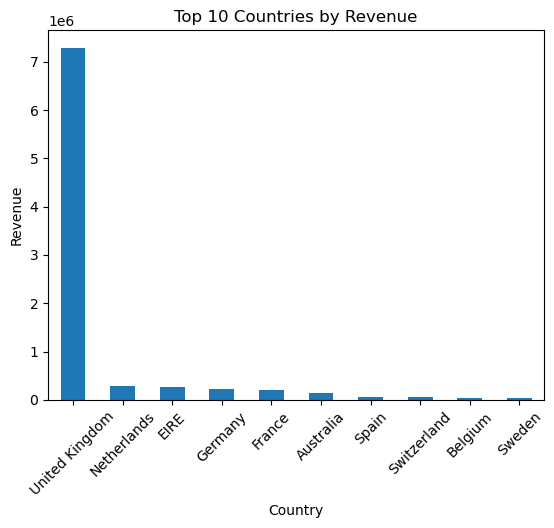

In [202]:
country_revenue.head(10).plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show() # Plot the top 10 countries by revenue to visualize which countries are generating the most sales

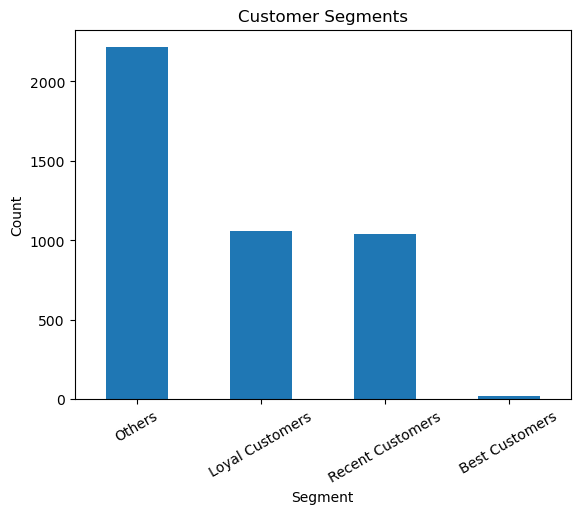

In [203]:
customer_df['Segment'].value_counts().plot(kind='bar')

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show() # Plot the distribution of customer segments to visualize the proportion of different customer groups based on their purchasing behavior

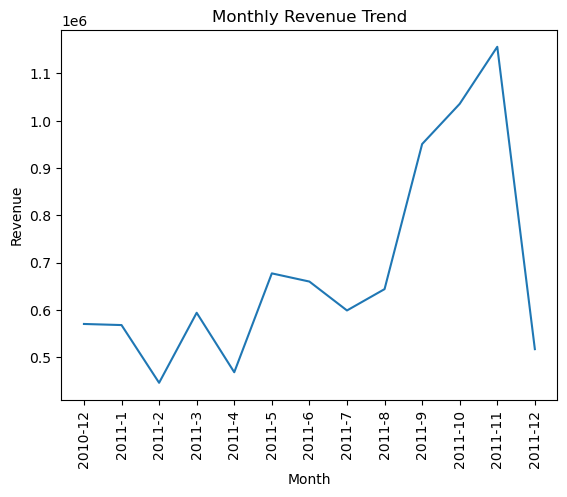

In [204]:
plt.figure()
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['TotalPrice'])

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.show() # Plot the monthly revenue trend over time to analyze seasonal patterns and growth trends in sales

In [205]:
import plotly.express as px # Import Plotly Express for interactive visualizations

In [206]:
fig = px.bar(
    top_products.head(10).reset_index(),
    x='TotalPrice',
    y='Description',
    orientation='h',
    title='Top 10 Products by Revenue'
)

fig.show() # Plot the top 10 products by revenue using an interactive horizontal bar chart for better visualization of product performance

In [207]:
fig = px.bar(
    country_revenue.head(10).reset_index(),
    x='Country',
    y='TotalPrice',
    title='Top Countries by Revenue'
)

fig.show() # Plot the top 10 countries by revenue using an interactive bar chart for better visualization of country performance

In [208]:
fig = px.line(
    monthly_revenue,
    x='YearMonth',
    y='TotalPrice',
    title='Monthly Revenue Trend'
)

fig.show() # Plot the monthly revenue trend over time using an interactive line chart for better visualization of seasonal patterns and growth trends in sales

In [209]:
segment_counts = customer_df['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

fig = px.pie(
    segment_counts,
    names='Segment',
    values='Count',
    title='Customer Segments'
)

fig.show() # Plot the distribution of customer segments using an interactive pie chart to visualize the proportion of different customer groups based on their purchasing behavior

# 6. Insights
- Top products like paper craft, little birdie drive most revenue
- Majority of customers are low-frequency buyers
- Revenue fluctuates monthly
- A small group of customers contributes most revenue
- There is a strong positive relationship between quantity and total revenue
- Unit price shows weaker correlation with quantity, suggesting pricing affects purchase volume

# 7. Conclusion
- This analysis provides insights into customer behavior and sales performance, which can help improve marketing and retention strategies.